In [14]:
# Import libraries
import pandas as pd
import numpy as np
import math
from scipy import sparse
import matplotlib.pyplot as plt
%matplotlib inline

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
%cd /content/drive/MyDrive/Colab Notebooks/MIE1622_Winter2026/Assignment_2

/content/drive/MyDrive/Colab Notebooks/MIE1622_Winter2026/Assignment_2


In [17]:
# Cplex installation on Google Colab
try:
    import cplex
except:
    !pip install cplex
    import cplex

In [18]:
# Cyipopt installation on Google Colab
try:
    import cyipopt as ipopt
except:
    !pip install cyipopt
    import cyipopt as ipopt

In [19]:
# Complete the following functions

def strat_buy_and_hold(x_init, cash_init, mu, Q, cur_prices):
   x_optimal = x_init
   cash_optimal = cash_init
   return x_optimal, cash_optimal

def strat_equally_weighted(x_init, cash_init, mu, Q, cur_prices):
    prices = np.asarray(cur_prices, dtype=float)
    n = prices.size
    Wealth = float(np.dot(x_init, prices) + cash_init)
    w = np.ones(n) / n

    dollar = Wealth * w
    x_optimal = np.floor(dollar / prices).astype(int)
    cost = float(np.dot(x_optimal, prices))
    cash_optimal = float(Wealth - cost)

    while cash_optimal >= prices.min() - 1e-12:
        affordable = np.where(prices <= cash_optimal + 1e-12)[0]
        if affordable.size == 0:
            break
        target_sh = dollar / prices
        gaps = target_sh - x_optimal
        i = affordable[np.argmax(gaps[affordable])]
        if prices[i] > cash_optimal + 1e-12:
            break
        x_optimal[i] += 1
        cash_optimal -= float(prices[i])

    return x_optimal, cash_optimal

def strat_min_variance(x_init, cash_init, mu, Q, cur_prices):
   prices = np.asarray(cur_prices, dtype=float)
   Q = np.asarray(Q, dtype=float)
   n = prices.size
   Wealth = float(np.dot(x_init, prices) + cash_init)

   # min-var
   ones = np.ones(n)
   Qr = Q + 1e-8 * np.eye(n)
   try:
       invQ = np.linalg.inv(Qr)
   except np.linalg.LinAlgError:
       invQ = np.linalg.pinv(Qr)

   w = invQ @ ones
   w = w / (ones @ w)
   w = np.maximum(w, 0.0)
   w = w / w.sum() if w.sum() > 0 else np.ones(n) / n

   dollar = Wealth * w
   x_optimal = np.floor(dollar / prices).astype(int)
   cost = float(np.dot(x_optimal, prices))
   cash_optimal = float(Wealth - cost)

   # greedy spend leftover
   while cash_optimal >= prices.min() - 1e-12:
       affordable = np.where(prices <= cash_optimal + 1e-12)[0]
       if affordable.size == 0:
           break
       target_sh = dollar / prices
       gaps = target_sh - x_optimal
       i = affordable[np.argmax(gaps[affordable])]
       if prices[i] > cash_optimal + 1e-12:
           break
       x_optimal[i] += 1
       cash_optimal -= float(prices[i])

   return x_optimal, cash_optimal

def strat_max_return(x_init, cash_init, mu, Q, cur_prices):
    prices = np.asarray(cur_prices, dtype=float)
    mu = np.asarray(mu, dtype=float)
    n = prices.size
    Wealth = float(np.dot(x_init, prices) + cash_init)

    # all-in best expected return asset (long-only)
    w = np.zeros(n)
    w[int(np.argmax(mu))] = 1.0
    dollar = Wealth * w
    x_optimal = np.floor(dollar / prices).astype(int)
    cost = float(np.dot(x_optimal, prices))
    cash_optimal = float(Wealth - cost)

    # use leftover to buy
    i = int(np.argmax(mu))
    while cash_optimal >= prices[i] - 1e-12:
        x_optimal[i] += 1
        cash_optimal -= float(prices[i])

    return x_optimal, cash_optimal

def strat_max_Sharpe(x_init, cash_init, mu, Q, cur_prices):
   prices = np.asarray(cur_prices, dtype=float)
   mu = np.asarray(mu, dtype=float)
   Q = np.asarray(Q, dtype=float)
   n = prices.size
   Wealth = float(np.dot(x_init, prices) + cash_init)

   # tangency approximation: w ∝ Q^{-1} mu
   Qr = Q + 1e-8 * np.eye(n)
   try:
       invQ = np.linalg.inv(Qr)
   except np.linalg.LinAlgError:
       invQ = np.linalg.pinv(Qr)

   w = invQ @ mu
   if np.all(w <= 1e-12):
       w = np.ones(n) / n
   w = np.maximum(w, 0.0)
   w = w / w.sum() if w.sum() > 0 else np.ones(n) / n

   dollar = Wealth * w
   x_optimal = np.floor(dollar / prices).astype(int)
   cost = float(np.dot(x_optimal, prices))
   cash_optimal = float(Wealth - cost)

   # greedy spend leftover
   while cash_optimal >= prices.min() - 1e-12:
       affordable = np.where(prices <= cash_optimal + 1e-12)[0]
       if affordable.size == 0:
           break
       target_sh = dollar / prices
       gaps = target_sh - x_optimal
       i = affordable[np.argmax(gaps[affordable])]
       if prices[i] > cash_optimal + 1e-12:
           break
       x_optimal[i] += 1
       cash_optimal -= float(prices[i])

   return x_optimal, cash_optimal

def strat_equal_risk_contr(x_init, cash_init, mu, Q, cur_prices):
   prices = np.asarray(cur_prices, dtype=float)
   Q = np.asarray(Q, dtype=float)
   n = prices.size
   Wealth = float(np.dot(x_init, prices) + cash_init)

   # heuristic ERC iteration (baseline that runs without IPOPT)
   w = np.ones(n) / n
   Qr = Q + 1e-10 * np.eye(n)

   for _ in range(400):
       Qw = Qr @ w
       var = float(w @ Qw)
       std = np.sqrt(max(var, 1e-16))
       mrc = Qw / max(std, 1e-16)
       rc = w * mrc
       target = std / n
       grad = (rc - target) * mrc
       w = w - 0.5 * grad
       w = np.maximum(w, 0.0)
       s = w.sum()
       w = w / s if s > 0 else np.ones(n) / n
       if np.max(np.abs(rc - target)) < 1e-6:
           break

   dollar = Wealth * w
   x_optimal = np.floor(dollar / prices).astype(int)
   cost = float(np.dot(x_optimal, prices))
   cash_optimal = float(Wealth - cost)

   while cash_optimal >= prices.min() - 1e-12:
       affordable = np.where(prices <= cash_optimal + 1e-12)[0]
       if affordable.size == 0:
           break
       target_sh = dollar / prices
       gaps = target_sh - x_optimal
       i = affordable[np.argmax(gaps[affordable])]
       if prices[i] > cash_optimal + 1e-12:
           break
       x_optimal[i] += 1
       cash_optimal -= float(prices[i])

   return x_optimal, cash_optimal


def strat_lever_max_Sharpe(x_init, cash_init, mu, Q, cur_prices):
    prices = np.asarray(cur_prices, dtype=float)
    Wealth = float(np.dot(x_init, prices) + cash_init)
    n = prices.size

    # max Sharpe direction (long-only approximation)
    try:
        invQ = np.linalg.inv(Q + 1e-8 * np.eye(n))
        w = invQ @ mu
    except:
        w = np.ones(n)

    w = np.maximum(w, 0)
    if w.sum() <= 1e-12:
        w = np.ones(n) / n
    else:
        w = w / w.sum()

    # Borrow an additional amount equal to Wealth
    borrowed = Wealth
    interest = borrowed * (r_rf / 6.0)   # one holding period ~ 2 months

    # Total risky exposure = 200% of current wealth
    lever_budget = 2.0 * Wealth

    dollar = lever_budget * w
    x_optimal = np.floor(dollar / prices).astype(int)
    cost = float(np.dot(x_optimal, prices))

    # leftover cash after buying risky assets, minus borrowing interest
    cash_optimal = float(lever_budget - cost - borrowed - interest)

    # if cash is too negative, reduce positions until feasible
    while cash_optimal < 0:
        pos = np.where(x_optimal > 0)[0]
        if pos.size == 0:
            break
        # sell one share of the most expensive held asset
        i = pos[np.argmax(prices[pos])]
        x_optimal[i] -= 1
        cash_optimal += float(prices[i])

    return x_optimal, cash_optimal

def strat_robust_optim(x_init, cash_init, mu, Q, cur_prices):
   prices = np.asarray(cur_prices, dtype=float)
   mu = np.asarray(mu, dtype=float)
   Q = np.asarray(Q, dtype=float)
   n = prices.size
   Wealth = float(np.dot(x_init, prices) + cash_init)

   # simple robust proxy
   delta = 0.0005
   mu_rob = mu - delta

   Qr = Q + 1e-8 * np.eye(n)
   try:
       invQ = np.linalg.inv(Qr)
   except np.linalg.LinAlgError:
       invQ = np.linalg.pinv(Qr)

   w = invQ @ mu_rob
   if np.all(w <= 1e-12):
       w = np.ones(n) / n
   w = np.maximum(w, 0.0)
   w = w / w.sum() if w.sum() > 0 else np.ones(n) / n

   dollar = Wealth * w
   x_optimal = np.floor(dollar / prices).astype(int)
   cost = float(np.dot(x_optimal, prices))
   cash_optimal = float(Wealth - cost)

   while cash_optimal >= prices.min() - 1e-12:
       affordable = np.where(prices <= cash_optimal + 1e-12)[0]
       if affordable.size == 0:
           break
       target_sh = dollar / prices
       gaps = target_sh - x_optimal
       i = affordable[np.argmax(gaps[affordable])]
       if prices[i] > cash_optimal + 1e-12:
           break
       x_optimal[i] += 1
       cash_optimal -= float(prices[i])

   return x_optimal, cash_optimal

def strat_tracking_index(x_init, cash_init, mu, Q, cur_prices):
    prices = np.asarray(cur_prices, dtype=float)
    Wealth = float(np.dot(x_init, prices) + cash_init)
    n = prices.size

    # Use benchmark weights if available
    global w_b

    if isinstance(w_b, np.ndarray):
        wb_now = np.asarray(w_b, dtype=float).reshape(-1)
        if wb_now.size != n:
            wb_now = np.ones(n) / n
    else:
        wb_now = np.ones(n) / n

    # Clean weights
    wb_now = np.maximum(wb_now, 0)
    if wb_now.sum() <= 1e-12:
        wb_now = np.ones(n) / n
    else:
        wb_now = wb_now / wb_now.sum()

    # Cardinality approximation: keep at most 10 stocks
    k = min(10, n)
    idx = np.argsort(-wb_now)[:k]

    w = np.zeros(n)
    w[idx] = wb_now[idx]

    if w.sum() <= 1e-12:
        w = np.ones(n) / n
    else:
        w = w / w.sum()

    # Buy integer shares
    dollar = Wealth * w
    x_optimal = np.floor(dollar / prices).astype(int)
    cost = float(np.dot(x_optimal, prices))
    cash_optimal = float(Wealth - cost)

    # Spend leftover cash sensibly
    while cash_optimal >= prices.min() - 1e-12:
        affordable = np.where(prices <= cash_optimal + 1e-12)[0]
        if affordable.size == 0:
            break

        target_shares = dollar / prices
        gaps = target_shares - x_optimal

        i = affordable[np.argmax(gaps[affordable])]
        if prices[i] > cash_optimal + 1e-12:
            break

        x_optimal[i] += 1
        cash_optimal -= float(prices[i])

    return x_optimal, cash_optimal

In [20]:
# Input file
input_file_prices = 'adjclose_2024_2025.csv'
#input_file_prices = 'adjclose_2008_2009.csv'
#input_file_prices = 'adjclose_2022_2022.csv'

# Read data into a dataframe
df = pd.read_csv(input_file_prices)

In [21]:
# Convert dates into array [year month day]
def convert_date_to_array(datestr):
    temp = [int(x) for x in datestr.split('/')]
    return [temp[-1], temp[0], temp[1]]

dates_array = np.array(list(df['Date'].apply(convert_date_to_array)))
data_prices = df.iloc[:, 1:].to_numpy()
dates = np.array(df['Date'])
# compute expected return and covariance matrix for period 1
day_ind_start0 = 0
day_ind_end0 = len(np.where(dates_array[:,0]==2023)[0])   # for 2024-2025 csv

#day_ind_end0 = len(np.where(dates_array[:,0]==2007)[0])   # for 2008-2009 csv
#day_ind_end0 = len(np.where(dates_array[:,0]==2021)[0])   # for 2022 csv

cur_returns0 = data_prices[day_ind_start0+1:day_ind_end0,:] / data_prices[day_ind_start0:day_ind_end0-1,:] - 1
mu = np.mean(cur_returns0, axis = 0)
Q = np.cov(cur_returns0.T)

# Remove datapoints for year 2023
data_prices = data_prices[day_ind_end0:,:]
dates_array = dates_array[day_ind_end0:,:]
dates = dates[day_ind_end0:]

# Initial positions in the portfolio
init_positions = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 15000, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 14349, 0])

# Initial value of the portfolio
init_value = np.dot(data_prices[0,:], init_positions)
print('\nInitial portfolio value = $ {}\n'.format(round(init_value, 2)))

# Initial portfolio weights
w_init = (data_prices[0,:] * init_positions) / init_value

# Number of periods, assets, trading days
N_periods = 6*len(np.unique(dates_array[:,0])) # 6 periods per year
N = len(df.columns)-1
N_days = len(dates)

# Annual risk-free rate for years 2024-2025 is 4.0%
r_rf = 0.04
# Annual risk-free rate for years 2008-2009 is 4.5%
r_rf2008_2009 = 0.045
# Annual risk-free rate for year 2022 is 3.75%
r_rf2022 = 0.0375

# Weights of assets in the benchmark portfolio S&P30 for years 2024-2025
#w_b = 0 # You should implement this by loading the weight file provided for you
df_bench = pd.read_csv('sp30_daily_weights_2024_2025.csv')
w_b = df_bench.iloc[0, 1:].to_numpy(dtype=float)
w_b = w_b / w_b.sum()
# Weights of assets in the benchmark portfolio S&P30 for years 2008-2009
df_bench_2008 = pd.read_csv('sp30_daily_weights_2008_2009.csv')
w_b2008_2009 = df_bench_2008.iloc[0, 1:].to_numpy(dtype=float)
w_b2008_2009 = w_b2008_2009 / w_b2008_2009.sum()
# Weights of assets in the benchmark portfolio S&P30 for year 2022
df_bench_2022 = pd.read_csv('sp30_daily_weights_2022_2022.csv')
w_b2022 = df_bench_2022.iloc[0, 1:].to_numpy(dtype=float)
w_b2022 = w_b2022 / w_b2022.sum()

# Number of strategies
strategy_functions = ['strat_buy_and_hold', 'strat_equally_weighted', 'strat_min_variance', 'strat_max_return', 'strat_max_Sharpe', 'strat_equal_risk_contr', 'strat_lever_max_Sharpe', 'strat_robust_optim', 'strat_tracking_index']
strategy_names     = ['Buy and Hold', 'Equally Weighted Portfolio', 'Mininum Variance Portfolio', 'Maximum Expected Return Portfolio', 'Maximum Sharpe Ratio Portfolio', 'Equal Risk Contributions Portfolio', 'Leveraged Max Sharpe Ratio Portfolio', 'Robust Optimization Portfolio', 'Benchmark Tracking Portfolio']
#N_strat = 1  # comment this in your code
N_strat = len(strategy_functions)  # uncomment this in your code
fh_array = [strat_buy_and_hold, strat_equally_weighted, strat_min_variance, strat_max_return, strat_max_Sharpe, strat_equal_risk_contr, strat_lever_max_Sharpe, strat_robust_optim, strat_tracking_index]

portf_value = [0] * N_strat
x = np.zeros((N_strat, N_periods), dtype=np.ndarray)
cash = np.zeros((N_strat, N_periods), dtype=np.ndarray)
trans_costs = np.zeros((N_strat, N_periods), dtype=np.ndarray)
for period in range(1, N_periods+1):
   # Compute current year and month, first and last day of the period

   # Depending on data/csv (i.e, time period), uncomment code
   if dates_array[0, 0] == 20:
       cur_year  = 20 + math.floor(period/7)
   else:
       cur_year  = 2024 + math.floor(period/7)

   # example for 2008-2009 data
   #if dates_array[0, 0] == 8:
   #    cur_year  = 8 + math.floor(period/7)
   #else:
   #    cur_year  = 2008 + math.floor(period/7)

   cur_month = 2*((period-1)%6) + 1
   day_ind_start = min([i for i, val in enumerate((dates_array[:,0] == cur_year) & (dates_array[:,1] == cur_month)) if val])
   day_ind_end = max([i for i, val in enumerate((dates_array[:,0] == cur_year) & (dates_array[:,1] == cur_month+1)) if val])
   print('\nPeriod {0}: start date {1}, end date {2}'.format(period, dates[day_ind_start], dates[day_ind_end]))

   # Prices for the current day
   cur_prices = data_prices[day_ind_start,:]

   # Execute portfolio selection strategies
   for strategy  in range(N_strat):

      # Get current portfolio positions
      if period == 1:
         curr_positions = init_positions
         curr_cash = 0 # the first period the cash account is 0 as all the cash is invested in stocks
         portf_value[strategy] = np.zeros((N_days, 1))
      else: # everything else after first period
         curr_positions = x[strategy, period-2]
         curr_cash = cash[strategy, period-2]

      # Compute strategy
      x[strategy, period-1], cash[strategy, period-1] = fh_array[strategy](curr_positions, curr_cash, mu, Q, cur_prices)

      # Compute transaction cost
      trans_fee = 0.005 # 0.5% of monetary value traded
      trans_costs[strategy, period-1] = 0 # modify according to your computations
      # Verify that strategy is feasible (you have enough budget to re-balance portfolio)
      # Check that cash account is >= 0
      # Check that we can buy new portfolio subject to transaction costs

      ###################### Insert your code here ############################

      # Transaction cost based on dollar volume traded
      x_new = x[strategy, period-1].copy()
      x_old = curr_positions.copy()

      trade_amount = np.sum(np.abs(x_new - x_old) * cur_prices)
      trans_costs[strategy, period-1] = trans_fee * trade_amount

      # Cash update after trades + transaction cost
      cash[strategy, period-1] = curr_cash - float(np.dot((x_new - x_old), cur_prices)) - float(trans_costs[strategy, period-1])

      # Identify leveraged strategy index
      LEVER_IDX = strategy_names.index('Leveraged Max Sharpe Ratio Portfolio')

      # Feasibility: If cash < 0, sell shares until cash >= 0
      if (strategy != LEVER_IDX) and (cash[strategy, period-1] < -1e-12):
          while cash[strategy, period-1] < -1e-12:
              sellable = np.where(x_new > 0)[0]
              if sellable.size == 0:
                  x_new = x_old.copy()
                  cash[strategy, period-1] = curr_cash
                  trans_costs[strategy, period-1] = 0.0
                  break

              j = sellable[np.argmax(cur_prices[sellable])]
              x_new[j] -= 1

              # Selling 1 share increases cash by price*(1 - trans_fee)
              cash[strategy, period-1] += float(cur_prices[j]) * (1.0 - trans_fee)

              # Extra transaction cost for 1-share sell
              trans_costs[strategy, period-1] += trans_fee * float(cur_prices[j])

          # update x and recompute trade_amount
          x[strategy, period-1] = x_new

      else:
          x[strategy, period-1] = x_new

      # Debug
      """
      print(strategy_names[strategy],
            "shares traded (after) =", int(np.sum(np.abs(x[strategy, period-1] - x_old))),
            "cash =", cash[strategy, period-1],
            "TC =", trans_costs[strategy, period-1])
      """


      # Compute portfolio value
      p_values = np.dot(data_prices[day_ind_start:day_ind_end+1,:], x[strategy, period-1]) + cash[strategy, period-1]
      portf_value[strategy][day_ind_start:day_ind_end+1] = np.reshape(p_values, (p_values.size,1))
      print('  Strategy "{0}", value begin = $ {1:.2f}, value end = $ {2:.2f}, Cash Acct = ${3:.2f}, TC = ${4:.2f}'.format( strategy_names[strategy],
             portf_value[strategy][day_ind_start][0], portf_value[strategy][day_ind_end][0], cash[strategy, period-1], trans_costs[strategy, period-1]))


   # Compute expected returns and covariances for the next period
   cur_returns = data_prices[day_ind_start+1:day_ind_end+1,:] / data_prices[day_ind_start:day_ind_end,:] - 1
   mu = np.mean(cur_returns, axis = 0)
   Q = np.cov(cur_returns.T)



Initial portfolio value = $ 1000012.45


Period 1: start date 01/02/2024, end date 02/29/2024
  Strategy "Buy and Hold", value begin = $ 1000012.45, value end = $ 1022178.73, Cash Acct = $0.00, TC = $0.00
  Strategy "Equally Weighted Portfolio", value begin = $ 990629.51, value end = $ 1033469.89, Cash Acct = $467.17, TC = $9382.93
  Strategy "Mininum Variance Portfolio", value begin = $ 990601.53, value end = $ 1014757.49, Cash Acct = $93.13, TC = $9410.91
  Strategy "Maximum Expected Return Portfolio", value begin = $ 989961.84, value end = $ 1375326.66, Cash Acct = $84.88, TC = $10050.61
  Strategy "Maximum Sharpe Ratio Portfolio", value begin = $ 990470.85, value end = $ 1049167.14, Cash Acct = $327.10, TC = $9541.59
  Strategy "Equal Risk Contributions Portfolio", value begin = $ 990621.81, value end = $ 1033606.02, Cash Acct = $459.16, TC = $9390.63
  Strategy "Leveraged Max Sharpe Ratio Portfolio", value begin = $ 991061.52, value end = $ 997414.02, Cash Acct = $-2250.83, TC = 

Running dataset: adjclose_2024_2025.csv


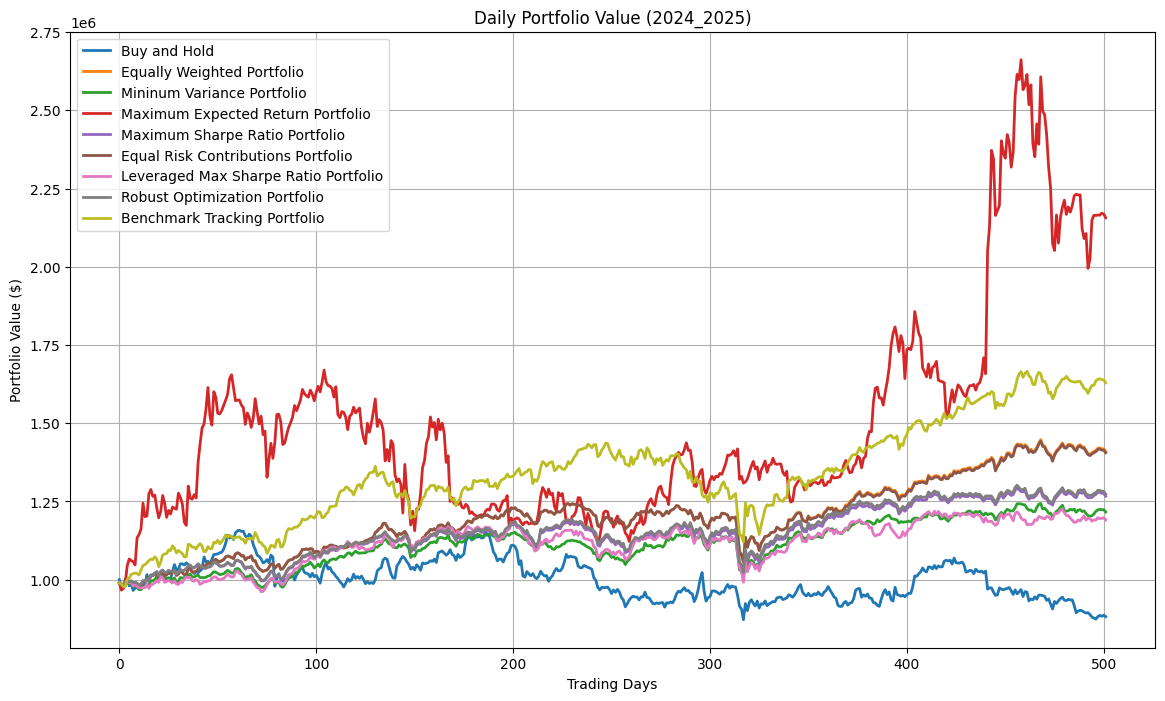

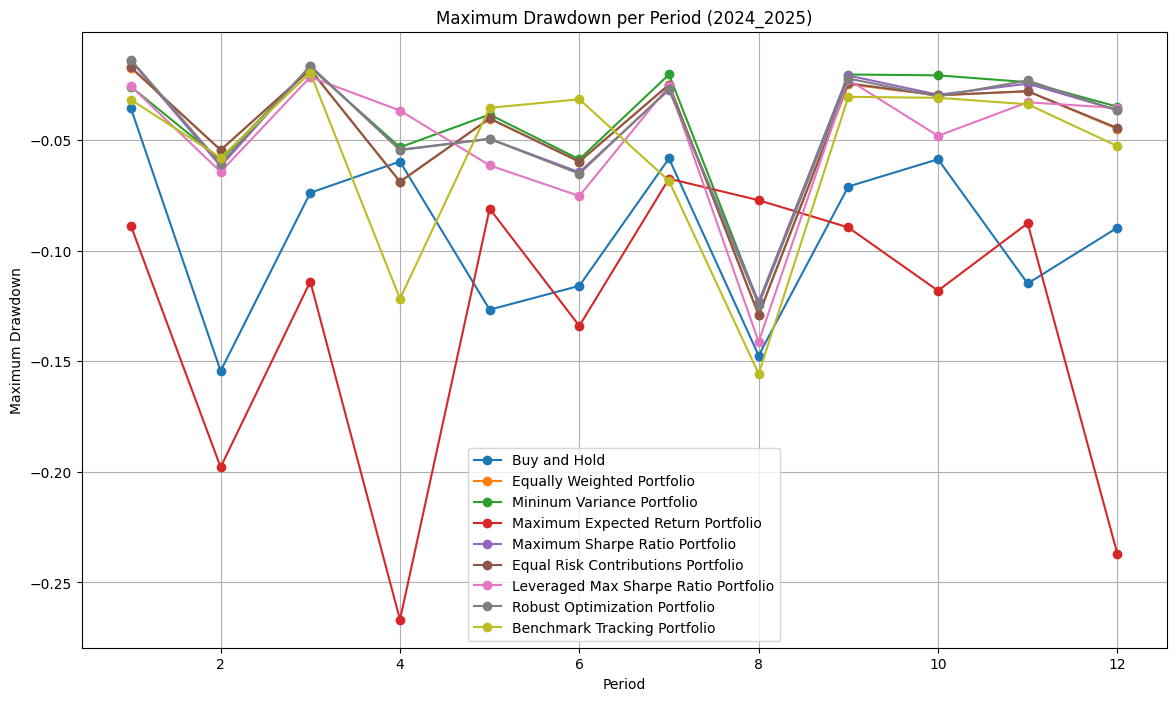

shares shape: (30,) prices shape: (30,) w shape: (30,)


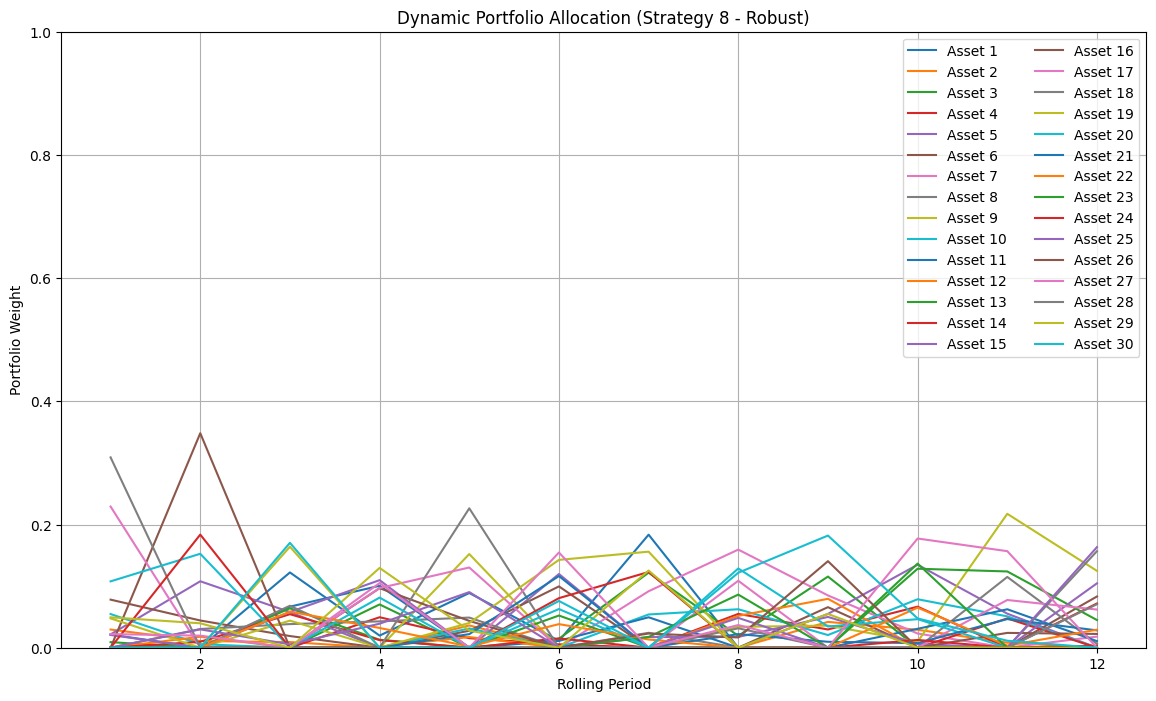

In [22]:
# Plot results
###################### Insert your code here ############################
print("Running dataset:", input_file_prices)
dataset_label = input_file_prices.replace('adjclose_', '').replace('.csv', '')

# Daily portfolio value
plt.figure(figsize=(14,8))

for strategy in range(len(strategy_names)):
    plt.plot(portf_value[strategy], linewidth=2, label=strategy_names[strategy])

plt.title(f"Daily Portfolio Value ({dataset_label})")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value ($)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# Maximum Drawdown
def build_bimonth_period_indices(dates_array, years=None):
    """
    Build 2-month periods:
    (1-2), (3-4), (5-6), (7-8), (9-10), (11-12)
    For each period, start = first trading day in that window,
    end = last trading day in that window.

    dates_array columns expected: [year, month, day]
    """
    y = dates_array[:, 0].astype(int)
    m = dates_array[:, 1].astype(int)

    if years is None:
        years = sorted(np.unique(y).tolist())

    start_list, end_list, labels = [], [], []

    for yy in years:
        for (m1, m2) in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12)]:
            idx = np.where((y == yy) & (m >= m1) & (m <= m2))[0]
            if len(idx) == 0:
                # This period doesn't exist in the dataset (e.g., partial year)
                continue
            start_list.append(int(idx[0]))
            end_list.append(int(idx[-1]))
            labels.append(f"{yy}-{m1:02d}~{m2:02d}")

    return start_list, end_list, labels

day_ind_start_list, day_ind_end_list, period_labels = build_bimonth_period_indices(dates_array)

def max_drawdown(series):
    cum_max = np.maximum.accumulate(series)
    drawdown = (series - cum_max) / cum_max
    return np.min(drawdown)

drawdowns = np.zeros((len(strategy_names), N_periods))

for s in range(len(strategy_names)):
    for p in range(N_periods):
        start = day_ind_start_list[p]
        end = day_ind_end_list[p]
        series = portf_value[s][start:end+1].flatten()
        drawdowns[s,p] = max_drawdown(series)

plt.figure(figsize=(14,8))

for s in range(len(strategy_names)):
    plt.plot(range(1, N_periods+1), drawdowns[s], marker='o', label=strategy_names[s])

plt.title(f"Maximum Drawdown per Period ({dataset_label})")
plt.xlabel("Period")
plt.ylabel("Maximum Drawdown")
plt.legend()
plt.grid(True)
plt.show()

# Strategy 8 allocation dynamics
robust_idx = strategy_names.index("Robust Optimization Portfolio")
weights = []

for p in range(N_periods):
    shares = np.asarray(x[robust_idx, p]).reshape(-1)

    start = day_ind_start_list[p]
    prices = np.asarray(data_prices[start]).reshape(-1)
    value = shares * prices
    denom = value.sum()
    w = value / denom if denom != 0 else np.zeros_like(value)

    if p == 0:
        print("shares shape:", shares.shape, "prices shape:", prices.shape, "w shape:", w.shape)

    weights.append(w)

weights = np.vstack(weights)

plt.figure(figsize=(14,8))
for asset in range(weights.shape[1]):
    plt.plot(range(1, N_periods+1), weights[:,asset], label=f"Asset {asset+1}")
plt.title("Dynamic Portfolio Allocation (Strategy 8 - Robust)")
plt.xlabel("Rolling Period")
plt.ylabel("Portfolio Weight")
plt.ylim(0,1)
plt.legend(ncol=2)
plt.grid(True)
plt.show()